# A parameterized heat equation with a physics-informed neural network

The earlier PINN examples in this repository approximate one solution for one
set of parameters. Here, one neural network approximates an entire family of
solutions. Its inputs specify position, time, the initial condition, and the
diffusivity.

## Learning objectives

After working through this notebook, you should be able to:

- distinguish a PINN for one solution from a finite-dimensional parameterized
  solution map;
- construct a trial solution that satisfies initial and boundary conditions
  exactly;
- use automatic differentiation to form a partial-differential-equation
  residual;
- validate a PINN on parameter combinations that were not used as labelled
  training data;
- explain why interpolation, extrapolation, and a small residual are different
  claims about model reliability.

The default configuration normally runs in well under two minutes on a recent
CPU. The notebook needs PyTorch, NumPy, and Matplotlib from `environment.yml`.
Training uses no exact or numerical solution values; the analytical solution is
reserved for validation.

## 1. Setup

The random seed makes a CPU execution reproducible for a fixed software
stack. Results can still differ between PyTorch versions and hardware
backends. CPU is the default because GPU launch and transfer overhead can
outweigh acceleration for this small network and collocation batch. Create
`TrainingConfig(use_cuda=True)` to benchmark your hardware rather than
assuming that an accelerator will be faster.

Problem and training settings are collected in immutable configuration
objects. Helper functions receive the configuration they need explicitly;
they do not depend on module-level constants.

In [1]:
import math
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


@dataclass(frozen=True)
class ProblemConfig:
    x_min: float = 0.0
    x_max: float = 1.0
    t_min: float = 0.0
    t_max: float = 1.0
    coefficient_min: float = -1.0
    coefficient_max: float = 1.0
    kappa_min: float = 0.05
    kappa_max: float = 0.20

    def input_bounds(self):
        lower = torch.tensor(
            [
                self.x_min,
                self.t_min,
                self.coefficient_min,
                self.coefficient_min,
                self.kappa_min,
            ]
        )
        upper = torch.tensor(
            [
                self.x_max,
                self.t_max,
                self.coefficient_max,
                self.coefficient_max,
                self.kappa_max,
            ]
        )
        return lower, upper


@dataclass(frozen=True)
class TrainingConfig:
    seed: int = 1729
    use_cuda: bool = False
    epochs: int = 5_000
    collocation_batch_size: int = 512
    learning_rate: float = 2.0e-3
    report_every: int = 500


def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


problem = ProblemConfig()
training = TrainingConfig()

seed_everything(training.seed)
using_cuda = training.use_cuda and torch.cuda.is_available()
device = torch.device("cuda" if using_cuda else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Define the family of problems

We solve the dimensionless heat equation

$$
\frac{\partial u}{\partial t}
=
\kappa\frac{\partial^2 u}{\partial x^2},
\qquad 0\leq x\leq 1,\quad 0\leq t\leq 1,
$$

with homogeneous Dirichlet boundary conditions

$$
u(0,t)=u(1,t)=0
$$

and the parameterized initial condition

$$
u(x,0)=a_1\sin(\pi x)+a_2\sin(2\pi x).
$$

The coefficients $a_1$ and $a_2$ select an initial temperature profile, while
$\kappa$ controls how quickly it diffuses. We train over
$a_1,a_2\in[-1,1]$ and $\kappa\in[0.05,0.20]$.

Restricting the initial condition to two basis functions makes this a
**finite-dimensional parameterized solution map**, not a neural operator for
arbitrary input functions.

In [2]:
def initial_profile(x, a1, a2, *, x_min, x_max):
    scaled_x = (x - x_min) / (x_max - x_min)
    return (
        a1 * torch.sin(math.pi * scaled_x)
        + a2 * torch.sin(2.0 * math.pi * scaled_x)
    )


def exact_solution(inputs, problem):
    # Used only to evaluate the trained PINN, never during training.
    x, t, a1, a2, kappa = inputs.unbind(dim=1)
    length = problem.x_max - problem.x_min
    elapsed_time = t - problem.t_min
    first_rate = (math.pi / length) ** 2
    second_rate = (2.0 * math.pi / length) ** 2
    profile_1 = initial_profile(
        x,
        a1,
        torch.zeros_like(a2),
        x_min=problem.x_min,
        x_max=problem.x_max,
    )
    profile_2 = initial_profile(
        x,
        torch.zeros_like(a1),
        a2,
        x_min=problem.x_min,
        x_max=problem.x_max,
    )
    return (
        torch.exp(-kappa * first_rate * elapsed_time) * profile_1
        + torch.exp(-kappa * second_rate * elapsed_time) * profile_2
    )

The second spatial mode has four times the decay rate of the first. Before
running the next cell, predict how increasing $\kappa$ changes each curve and
which mode will disappear first.

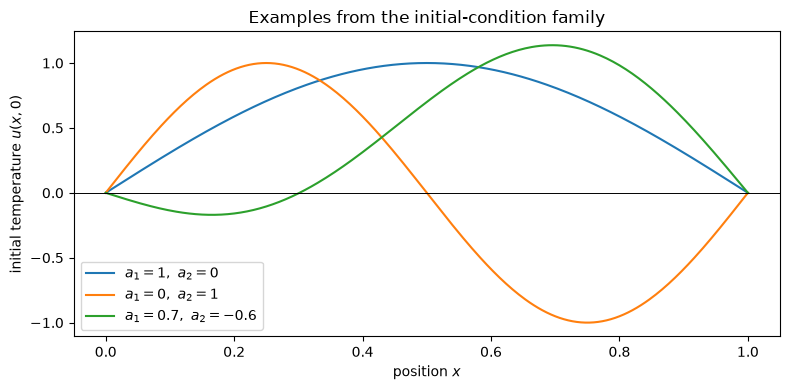

In [3]:
x_plot = torch.linspace(problem.x_min, problem.x_max, 301)
initial_conditions = [
    (1.0, 0.0, r"$a_1=1,\ a_2=0$"),
    (0.0, 1.0, r"$a_1=0,\ a_2=1$"),
    (0.7, -0.6, r"$a_1=0.7,\ a_2=-0.6$"),
]

fig, ax = plt.subplots(figsize=(8, 4))
for a1, a2, label in initial_conditions:
    profile = initial_profile(
        x_plot,
        a1,
        a2,
        x_min=problem.x_min,
        x_max=problem.x_max,
    )
    ax.plot(x_plot, profile, label=label)
ax.set(xlabel=r"position $x$", ylabel=r"initial temperature $u(x,0)$")
ax.axhline(0.0, color="black", linewidth=0.7)
ax.legend()
ax.set_title("Examples from the initial-condition family")
fig.tight_layout()

## 3. Enforce the conditions by construction

Let $N_\Phi(x,t,a_1,a_2,\kappa)$ be an ordinary multilayer perceptron with
trainable weights and biases $\Phi$. Rather than using its output directly, we
define

$$
\hat u_\Phi(x,t;a_1,a_2,\kappa)
=u(x,0)+t\,x(1-x)N_\Phi(x,t,a_1,a_2,\kappa).
$$

At $t=0$, the correction vanishes and the initial condition is exact. At
$x=0$ and $x=1$, both the sine modes and the factor $x(1-x)$ vanish, so the
boundary conditions are exact as well. This is a **hard-constrained trial
solution**. The network only has to learn an interior correction.

The five network inputs are scaled to $[-1,1]$. The scaling bounds are
registered as model buffers, so they move with the model and are stored in its
state. Scaling changes what the network sees, but automatic differentiation
still starts from the physical $x$ and $t$ values.

In [4]:
class ParametricHeatPINN(nn.Module):
    def __init__(self, problem, width=32, hidden_layers=3):
        super().__init__()
        layers = [nn.Linear(5, width), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.network = nn.Sequential(*layers)

        input_lower, input_upper = problem.input_bounds()
        self.register_buffer("input_lower", input_lower)
        self.register_buffer("input_upper", input_upper)

    def forward(self, inputs):
        x, t, a1, a2, _ = inputs.unbind(dim=1)
        scaled_inputs = 2.0 * (
            (inputs - self.input_lower) / (self.input_upper - self.input_lower)
        ) - 1.0

        x_min = self.input_lower[0]
        x_max = self.input_upper[0]
        t_initial = self.input_lower[1]
        starting_profile = initial_profile(
            x,
            a1,
            a2,
            x_min=x_min,
            x_max=x_max,
        )
        correction = self.network(scaled_inputs).squeeze(dim=1)
        constraint_factor = (t - t_initial) * (x - x_min) * (x_max - x)
        return starting_profile + constraint_factor * correction


model = ParametricHeatPINN(problem).to(device)
print(model)

ParametricHeatPINN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


The hard constraints should hold even though the network has random weights.
Predict the result before running this numerical check. Values near
$10^{-7}$ are zero to single-precision round-off.

In [5]:
def random_parameters(n, problem, device):
    coefficient_width = problem.coefficient_max - problem.coefficient_min
    a1 = problem.coefficient_min + coefficient_width * torch.rand(
        n, device=device
    )
    a2 = problem.coefficient_min + coefficient_width * torch.rand(
        n, device=device
    )
    kappa = problem.kappa_min + (
        problem.kappa_max - problem.kappa_min
    ) * torch.rand(n, device=device)
    return a1, a2, kappa


with torch.inference_mode():
    n_check = 200
    x = problem.x_min + (problem.x_max - problem.x_min) * torch.rand(
        n_check, device=device
    )
    a1, a2, kappa = random_parameters(n_check, problem, device)
    initial_inputs = torch.column_stack(
        [x, torch.full_like(x, problem.t_min), a1, a2, kappa]
    )
    initial_error = (
        model(initial_inputs) - exact_solution(initial_inputs, problem)
    ).abs().max()

    boundary_x = torch.cat(
        [
            torch.full((n_check // 2,), problem.x_min, device=device),
            torch.full((n_check // 2,), problem.x_max, device=device),
        ]
    )
    t = problem.t_min + (problem.t_max - problem.t_min) * torch.rand(
        n_check, device=device
    )
    a1, a2, kappa = random_parameters(n_check, problem, device)
    boundary_inputs = torch.column_stack([boundary_x, t, a1, a2, kappa])
    boundary_error = model(boundary_inputs).abs().max()

print(f"Maximum initial-condition error: {initial_error.item():.3e}")
print(f"Maximum boundary-condition error: {boundary_error.item():.3e}")

Maximum initial-condition error: 0.000e+00
Maximum boundary-condition error: 2.357e-07


## 4. Build the physics loss

For each collocation point we compute

$$
r_\Phi=
\frac{\partial \hat u_\Phi}{\partial t}
-\kappa\frac{\partial^2 \hat u_\Phi}{\partial x^2}.
$$

The loss is the mean of $r_\Phi^2$. There is no labelled target value and no
separate initial- or boundary-condition loss.

`torch.autograd.grad` differentiates the network output with respect to its
inputs. The model contains no operations that mix examples within a batch, so
the gradient obtained from the summed outputs contains the derivative for each
corresponding row.

In [6]:
def sample_collocation_points(n, problem, device):
    x = problem.x_min + (problem.x_max - problem.x_min) * torch.rand(
        n, device=device
    )
    t = problem.t_min + (problem.t_max - problem.t_min) * torch.rand(
        n, device=device
    )
    a1, a2, kappa = random_parameters(n, problem, device)
    return torch.column_stack([x, t, a1, a2, kappa]).requires_grad_(True)


def physics_residual(model, inputs, *, create_parameter_graph=True):
    u = model(inputs)
    first_derivatives = torch.autograd.grad(
        u,
        inputs,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]
    du_dx = first_derivatives[:, 0]
    du_dt = first_derivatives[:, 1]
    d2u_dx2 = torch.autograd.grad(
        du_dx,
        inputs,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=create_parameter_graph,
    )[0][:, 0]
    return du_dt - inputs[:, 4] * d2u_dx2

## 5. Train across time, space, and parameters

Every epoch samples new values of $(x,t,a_1,a_2,\kappa)$. Consequently, the
loss need not decrease monotonically: adjacent epochs use different
collocation points. The analytical solution is not called by the training
loop.

In [7]:
def train_pinn(model, problem, training, device):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=training.learning_rate,
    )
    loss_history = []

    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    model.train()
    for epoch in range(training.epochs):
        inputs = sample_collocation_points(
            training.collocation_batch_size,
            problem,
            device,
        )
        optimizer.zero_grad(set_to_none=True)
        residual = physics_residual(model, inputs)
        loss = residual.square().mean()
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        if (epoch + 1) % training.report_every == 0:
            print(f"epoch {epoch + 1:5d}: physics loss = {loss.item():.3e}")

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - start_time
    return np.asarray(loss_history), elapsed_seconds


loss_history, elapsed_seconds = train_pinn(
    model,
    problem,
    training,
    device,
)
print(f"Training time: {elapsed_seconds:.1f} s")

epoch   500: physics loss = 6.439e-02


epoch  1000: physics loss = 2.266e-02


epoch  1500: physics loss = 1.334e-02


epoch  2000: physics loss = 1.156e-02


epoch  2500: physics loss = 4.647e-03


epoch  3000: physics loss = 7.178e-03


epoch  3500: physics loss = 5.673e-03


epoch  4000: physics loss = 1.821e-03


epoch  4500: physics loss = 2.387e-03


epoch  5000: physics loss = 2.130e-03
Training time: 25.8 s


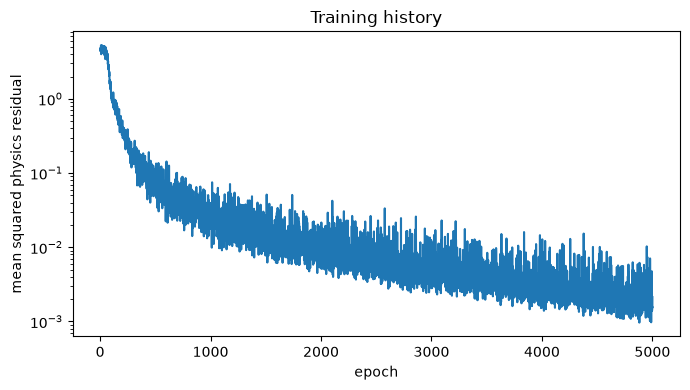

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(np.arange(1, len(loss_history) + 1), loss_history)
ax.set(xlabel="epoch", ylabel="mean squared physics residual")
ax.set_title("Training history")
fig.tight_layout()

## 6. Validate on unseen parameter combinations

A small training residual is not sufficient evidence that the predicted
solution is accurate throughout the domain. Because this problem has an
analytical solution, we can test complete trajectories for parameter
combinations that were not supplied as labelled data.

The three cases below are within the training ranges. They are *held out* in
the sense that the continuously sampled training process was never given their
analytical solution values—not in the sense that random collocation could
never draw nearby parameter values.

In [9]:
def make_evaluation_inputs(
    a1,
    a2,
    kappa,
    problem,
    device,
    *,
    n_x=101,
    n_t=51,
):
    x = torch.linspace(problem.x_min, problem.x_max, n_x, device=device)
    t = torch.linspace(problem.t_min, problem.t_max, n_t, device=device)
    tt, xx = torch.meshgrid(t, x, indexing="ij")
    inputs = torch.column_stack(
        [
            xx.ravel(),
            tt.ravel(),
            torch.full_like(xx.ravel(), a1),
            torch.full_like(xx.ravel(), a2),
            torch.full_like(xx.ravel(), kappa),
        ]
    )
    return inputs, x, t


def solution_error(model, a1, a2, kappa, problem, device, **grid_options):
    inputs, _, _ = make_evaluation_inputs(
        a1,
        a2,
        kappa,
        problem,
        device,
        **grid_options,
    )
    model.eval()
    with torch.inference_mode():
        prediction = model(inputs)
        reference = exact_solution(inputs, problem)
    difference = prediction - reference
    relative_l2 = (
        torch.linalg.vector_norm(difference)
        / torch.linalg.vector_norm(reference)
    )
    return relative_l2.item(), difference.abs().max().item()


held_out_cases = [
    (0.75, -0.50, 0.080),
    (-0.40, 0.90, 0.170),
    (0.20, -0.80, 0.125),
]

print("   a1      a2    kappa    relative L2    maximum error")
for case in held_out_cases:
    relative_l2, maximum_error = solution_error(
        model,
        *case,
        problem,
        device,
    )
    print(
        f"{case[0]:6.2f}  {case[1]:6.2f}  {case[2]:7.3f}"
        f"    {relative_l2:10.3e}    {maximum_error:10.3e}"
    )

   a1      a2    kappa    relative L2    maximum error
  0.75   -0.50    0.080     2.111e-02     2.159e-02
 -0.40    0.90    0.170     2.930e-02     1.724e-02
  0.20   -0.80    0.125     1.585e-02     1.112e-02


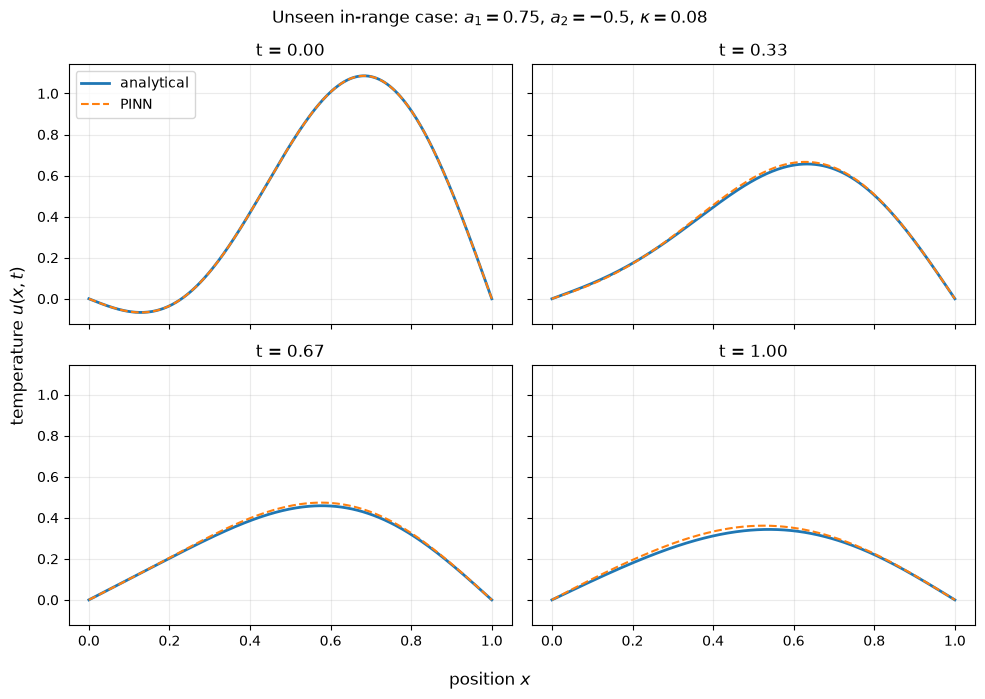

In [10]:
a1, a2, kappa = held_out_cases[0]
times_to_plot = np.linspace(problem.t_min, problem.t_max, 4)
x = torch.linspace(problem.x_min, problem.x_max, 301, device=device)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
model.eval()
for ax, current_time in zip(axes.flat, times_to_plot):
    inputs = torch.column_stack(
        [
            x,
            torch.full_like(x, current_time),
            torch.full_like(x, a1),
            torch.full_like(x, a2),
            torch.full_like(x, kappa),
        ]
    )
    with torch.inference_mode():
        predicted = model(inputs).cpu()
        exact = exact_solution(inputs, problem).cpu()
    ax.plot(x.cpu(), exact, label="analytical", linewidth=2)
    ax.plot(x.cpu(), predicted, "--", label="PINN")
    ax.set_title(f"t = {current_time:.2f}")
    ax.grid(alpha=0.25)

axes[0, 0].legend()
fig.supxlabel(r"position $x$")
fig.supylabel(r"temperature $u(x,t)$")
fig.suptitle(
    rf"Unseen in-range case: $a_1={a1}$, $a_2={a2}$, $\kappa={kappa}$"
)
fig.tight_layout()

### Check the residual independently

The next estimate uses fresh collocation points. Compare its scale with the
trajectory errors above. They measure different things: a local differential
equation residual and accumulated solution error, respectively.

In [11]:
model.eval()
validation_inputs = sample_collocation_points(5_000, problem, device)
validation_residual = physics_residual(
    model,
    validation_inputs,
    create_parameter_graph=False,
).detach()

print(
    "Fresh-collocation residual RMSE: "
    f"{validation_residual.square().mean().sqrt().item():.3e}"
)
print(
    "Fresh-collocation maximum absolute residual: "
    f"{validation_residual.abs().max().item():.3e}"
)

Fresh-collocation residual RMSE: 4.469e-02
Fresh-collocation maximum absolute residual: 1.011e+00


## 7. Exercise: interpolation is not extrapolation

**Timebox: 10 minutes.** Before running the cell, rank the following cases by
expected error and justify the ranking.

1. A smooth, first-mode-dominated profile inside all training ranges.
2. A second-mode-dominated profile inside all training ranges.
3. A diffusivity outside the training interval.
4. An initial-condition coefficient outside the training interval.

Then compare the numerical result with your prediction. Do not infer a general
law from one training run: explain which result is consistent with your
reasoning and which result would require repeated runs or a broader test grid.

In [12]:
reasoning_cases = {
    "first mode, in range": (0.90, 0.10, 0.100),
    "second mode, in range": (0.10, 0.90, 0.100),
    "diffusivity extrapolation": (0.90, 0.10, 0.250),
    "coefficient extrapolation": (0.10, 2.00, 0.100),
}

print("case                         relative L2    maximum error")
for label, case in reasoning_cases.items():
    relative_l2, maximum_error = solution_error(model, *case, problem, device)
    print(f"{label:28s} {relative_l2:10.3e}    {maximum_error:10.3e}")

case                         relative L2    maximum error
first mode, in range          3.500e-02     3.261e-02
second mode, in range         1.471e-02     1.096e-02
diffusivity extrapolation     1.187e-01     8.093e-02
coefficient extrapolation     2.633e-01     3.361e-01


### Map error across the parameter family

A few attractive trajectories can hide uneven performance. The heat map below
holds $\kappa$ fixed and evaluates a grid of unseen coefficient combinations.
Look for structure: does error depend only on the size of the coefficients, or
also on which spatial mode dominates? The center is marked `N/A` because the
relative error is undefined when both the prediction and exact solution are
identically zero.

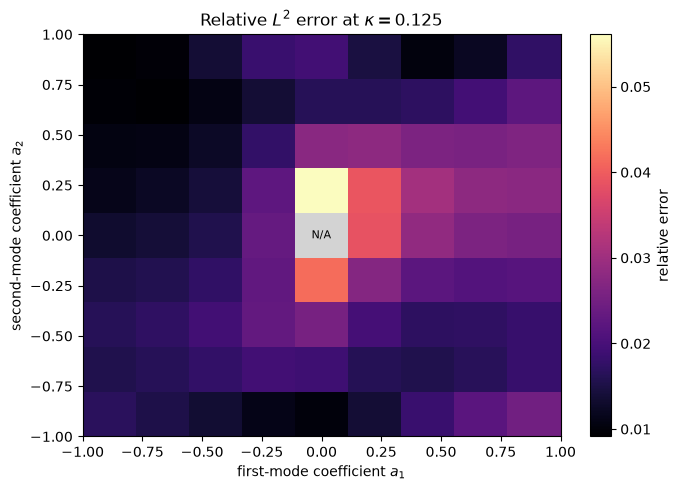

In [13]:
grid_size = 9
a1_values = np.linspace(
    problem.coefficient_min,
    problem.coefficient_max,
    grid_size,
)
a2_values = np.linspace(
    problem.coefficient_min,
    problem.coefficient_max,
    grid_size,
)
relative_errors = np.empty((len(a2_values), len(a1_values)))

for row, a2 in enumerate(a2_values):
    for column, a1 in enumerate(a1_values):
        if a1 == 0.0 and a2 == 0.0:
            relative_errors[row, column] = np.nan
            continue
        relative_errors[row, column], _ = solution_error(
            model,
            float(a1),
            float(a2),
            0.125,
            problem,
            device,
            n_x=51,
            n_t=31,
        )

fig, ax = plt.subplots(figsize=(7, 5))
masked_errors = np.ma.masked_invalid(relative_errors)
colormap = plt.colormaps["magma"].copy()
colormap.set_bad(color="lightgray")
image = ax.imshow(
    masked_errors,
    origin="lower",
    extent=[
        problem.coefficient_min,
        problem.coefficient_max,
        problem.coefficient_min,
        problem.coefficient_max,
    ],
    aspect="auto",
    cmap=colormap,
)
ax.set(
    xlabel=r"first-mode coefficient $a_1$",
    ylabel=r"second-mode coefficient $a_2$",
    title=r"Relative $L^2$ error at $\kappa=0.125$",
)
ax.text(
    0.0,
    0.0,
    "N/A",
    ha="center",
    va="center",
    fontsize=8,
)
fig.colorbar(image, ax=ax, label="relative error")
fig.tight_layout()

## 8. Takeaways and limitations

- The network represents $\hat u(x,t;a_1,a_2,\kappa)$ rather than one fixed
  trajectory. Training is amortized over a family of initial conditions and
  diffusivities.
- The trial-solution construction satisfies the initial and boundary
  conditions to floating-point precision without balancing several loss terms.
- The physics residual supplies the training signal, while the analytical
  solution provides independent validation.
- Good interpolation does not establish reliable extrapolation. A residual,
  several trajectories, and a parameter-space error map provide complementary
  evidence.
- This controlled problem is deliberately easier than many realistic PINN
  applications. A conventional analytical or numerical solver is faster and
  more reliable here. The example demonstrates the idea of a reusable
  parameterized surrogate; it does not establish that PINNs are generally
  superior differential-equation solvers.
- The initial condition is restricted to two coefficients. Learning a mapping
  from an arbitrary function to its solution would require an operator-learning
  formulation rather than simply adding more scalar inputs indefinitely.

## References

- M. Raissi, P. Perdikaris, and G. E. Karniadakis,
  [Physics-informed neural networks](https://doi.org/10.1016/j.jcp.2018.10.045),
  *Journal of Computational Physics* 378 (2019), 686–707.
- A. S. Krishnapriyan *et al.*,
  [Characterizing possible failure modes in physics-informed neural networks](https://proceedings.neurips.cc/paper/2021/hash/df438e5206f31600e6ae4af72f2725f1-Abstract.html),
  NeurIPS 2021.